In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm


# 1. Theoretical Background

## 1.1 Monte Carlo Methods
**Monte Carlo (MC) methods** are a class of learning algorithms that learn directly from **sampling episodes** without requiring a model of the environment dynamics. Unlike Dynamic Programming, MC methods do not require knowledge of the transition probabilities:

$$P(s', r \mid s, a)$$

## 1.2 The Control Problem
The goal of the control problem is to find the **optimal policy** $\pi^*$ that maximizes the expected return. In the context of Blackjack, this is defined as a **finite Markov Decision Process (MDP)** where the game eventually ends (episodic), yielding a terminal reward:

$$R \in \{+1, 0, -1\}$$

## 1.3 Monte Carlo with Exploring Starts
A significant challenge in MC methods is **exploration**. If a policy is deterministic, the agent may never visit certain state–action pairs, leaving them unestimated. This is addressed using **Exploring Starts (MC-ES)**:

* **Requirement**: Every state–action pair $(s,a)$ must have a non-zero probability of being selected as the start of an episode.
* **Implementation**: I satisfy this by choosing the initial state and action for every episode randomly.

This ensures that the entire state–action space is explored over time, allowing the algorithm to converge toward the optimal policy $\pi^*$.

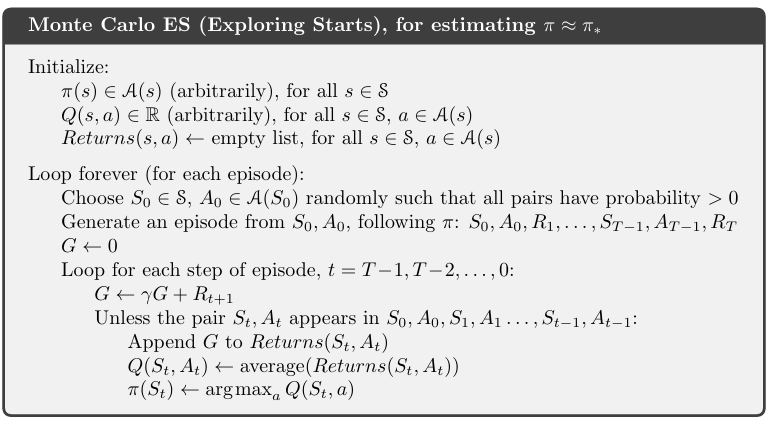

###  Hand Value and Mechanics

* **`draw_card()`**: Simulates drawing from an infinite deck using sampling with replacement. Cards $11$–$13$ are mapped to $10$ to preserve the correct card deck probabilities with replacement.
* **`hand_value()`**: Implements the logic of the **usable ace**. A usable ace is defined as an ace that can be counted as $11$ without the total hand value exceeding $21$.

In [ ]:
# --- 1. THE MECHANICS ---
def draw_card():
    # Correct probability: 1/13 for A-9, 4/13 for 10
    rank = random.randint(1, 13)
    return min(rank, 10)

def hand_value(hand):
    s = sum(hand)
    if 1 in hand and s + 10 <= 21:
        return s + 10, True
    return s, False


# 2. Generating Episodes with Exploring Starts

The `generate_episode` function serves as the external loop of the Monte Carlo algorithm, simulating individual game episodes. It satisfies the **Exploring Starts** requirement by explicitly forcing a random initial state and action for every new episode.

## 2.1 Initializing the Random State
To ensure that every possible state is visited and estimated, the game does not begin from a standard deal. Instead, the player is "teleported" into a random scenario with the following parameters:

* **Player sum**: Uniformly chosen between $12$ and $21$.
* **Dealer card**: Uniformly chosen between $1$ and $10$.
* **Usable ace**: Randomly assigned (`True` or `False`).
* **First action**: Randomly chosen (**Hit** or **Stick**).

## 2.2 Engineering the Hand
Because the environment requires actual card objects to process "hits," the code creates a hand that matches the randomly generated state. In Blackjack, the specific cards are irrelevant to the state; only the total sum and the presence of a usable ace matter. This allows the code to force a hand, such as `[10, player_sum - 10]`, to match the starting state.

## 2.3 The Interaction Loop
After initialization, the episode evolves by following the current policy $\pi(s)$.

* **State space**: Defined by the triple $(\text{player\_sum}, \text{dealer\_card}, \text{usable\_ace})$.
* **Heuristic constraint**: If the player's sum is less than $12$, the player always hits, as there is zero risk of "busting". The policy is only consulted for decision-making when the sum is between $12$ and $21$.

In [ ]:
# --- 2. GENERATE EPISODE ---
def generate_episode(policy):
    episode = []

    # Random Start
    p_sum = random.randint(12, 21)
    d_card = draw_card() # FIXED: Now uses correct distribution
    usable_ace = bool(random.getrandbits(1))
    action = random.choice([0, 1])

    # Construct Hand
    if usable_ace:
        player_hand = [1, p_sum - 11] # Covers A+A (12) to A+10 (21)
    else:
        if p_sum == 21:
            player_hand = [10, 5, 6]
        else:
            player_hand = [10, p_sum - 10]

    dealer_hand = [d_card, draw_card()]
    state = (p_sum, d_card, usable_ace)

    while True:
        episode.append((state, action))

        if action == 0: # STICK
            break

        player_hand.append(draw_card())
        p_sum, usable_ace = hand_value(player_hand)

        if p_sum > 21:
            return episode, -1

        state = (p_sum, d_card, usable_ace)

        if p_sum < 12:
            action = 1
        else:
            action = policy.get(state, 1)

    d_sum, _ = hand_value(dealer_hand)
    while d_sum < 17:
        dealer_hand.append(draw_card())
        d_sum, _ = hand_value(dealer_hand)

    p_sum, _ = hand_value(player_hand)

    if d_sum > 21: return episode, 1
    if p_sum > d_sum: return episode, 1
    if p_sum < d_sum: return episode, -1
    return episode, 0

# 3. Episode Outcome and Rewards

Once the player chooses to **Stick** (`Action = 0`) or "busts" (exceeds 21), control transitions to the dealer.

## 3.1 Dealer Policy
The dealer follows a **fixed policy**:
* The dealer must continue to **Hit** until their hand sum is $17$ or higher.
* Once the sum reaches $17$ or more, the dealer must **Stick**.

## 3.2 Reward Signal
The reward signal $R$ is defined at the end of the episode:
* **+1**: Player wins (dealer busts or player sum > dealer sum).
* **-1**: Dealer wins (player busts or dealer sum > player sum).
* **0**: Draw (**push**).

This terminal outcome represents the **return** $G$ for all state–action pairs visited during the episode and is used to update the action–value function $Q(s,a)$.

---

# 4. Policy Evaluation and Improvement

In Reinforcement Learning, the control problem is commonly solved using **Policy Iteration**, an alternating two-step procedure:
* **Policy Evaluation**: Estimating the action–value function $Q(s,a)$ for the current policy.
* **Policy Improvement**: Updating the policy to be greedy with respect to the current $Q$-values.

## 4.1 First-Visit Monte Carlo Update
This implementation adopts the **First-Visit Monte Carlo** method. Only the return following the **first** occurrence of a state–action pair within an episode is used for learning.

The update rule is implemented as a running average:
$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \frac{1}{N(S_t, A_t)} [G - Q(S_t, A_t)]$$

where $N(S_t, A_t)$ denotes the visit count. This approach avoids storing all past returns by maintaining a running average.

In [ ]:
# --- 3. MONTE CARLO CONTROL ---
def train(num_episodes=500000):
    Q = {}
    Returns_Count = {}
    policy = {}

    # Initialize
    for s in range(12, 22):
        for d in range(1, 11):
            for u in [True, False]:
                state = (s, d, u)
                policy[state] = 0 if s >= 20 else 1 # Optimistic init
                Q[(state, 0)] = 0.0
                Q[(state, 1)] = 0.0
                Returns_Count[(state, 0)] = 0
                Returns_Count[(state, 1)] = 0

    for i in range(num_episodes):
        episode, G = generate_episode(policy)
        visited = set()

        for state, action in episode:
            if state[0] < 12: continue

            if (state, action) not in visited:
                visited.add((state, action))

                Returns_Count[(state, action)] += 1
                N = Returns_Count[(state, action)]

                # Incremental Mean Update
                Q[(state, action)] += (1.0/N) * (G - Q[(state, action)])

                # Update Policy
                if Q[(state, 1)] > Q[(state, 0)]:
                    policy[state] = 1
                else:
                    policy[state] = 0

        if (i+1) % 100000 == 0:
            print(f"\rEpisode {i+1}/{num_episodes} completed.", end="")
    print()
    return policy, Q


Episode 9100000/9100000 completed.


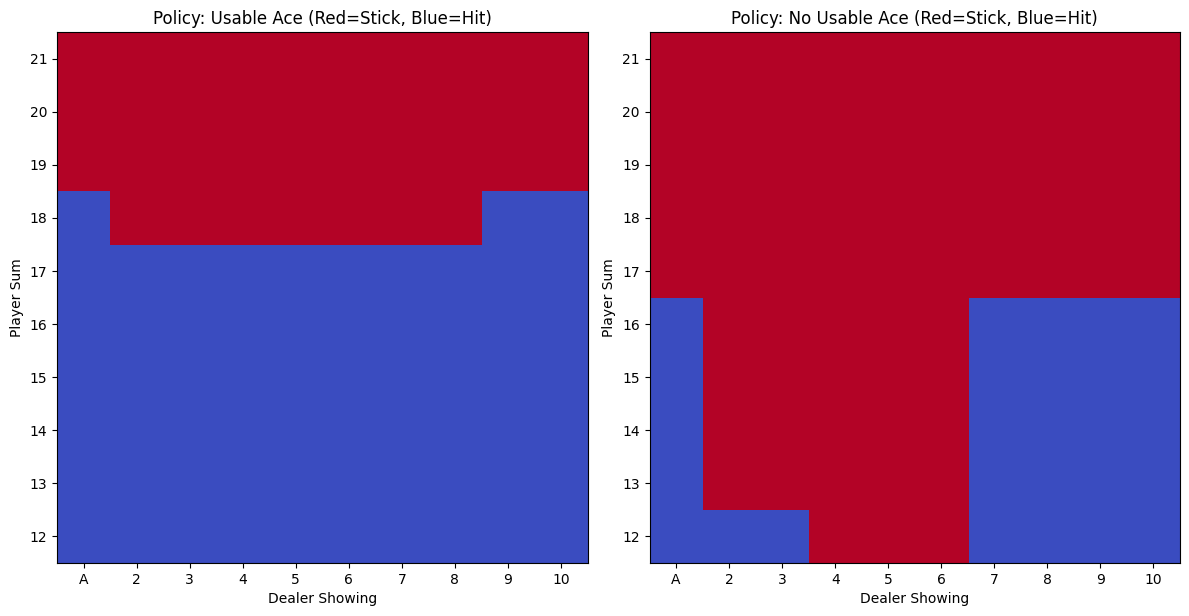

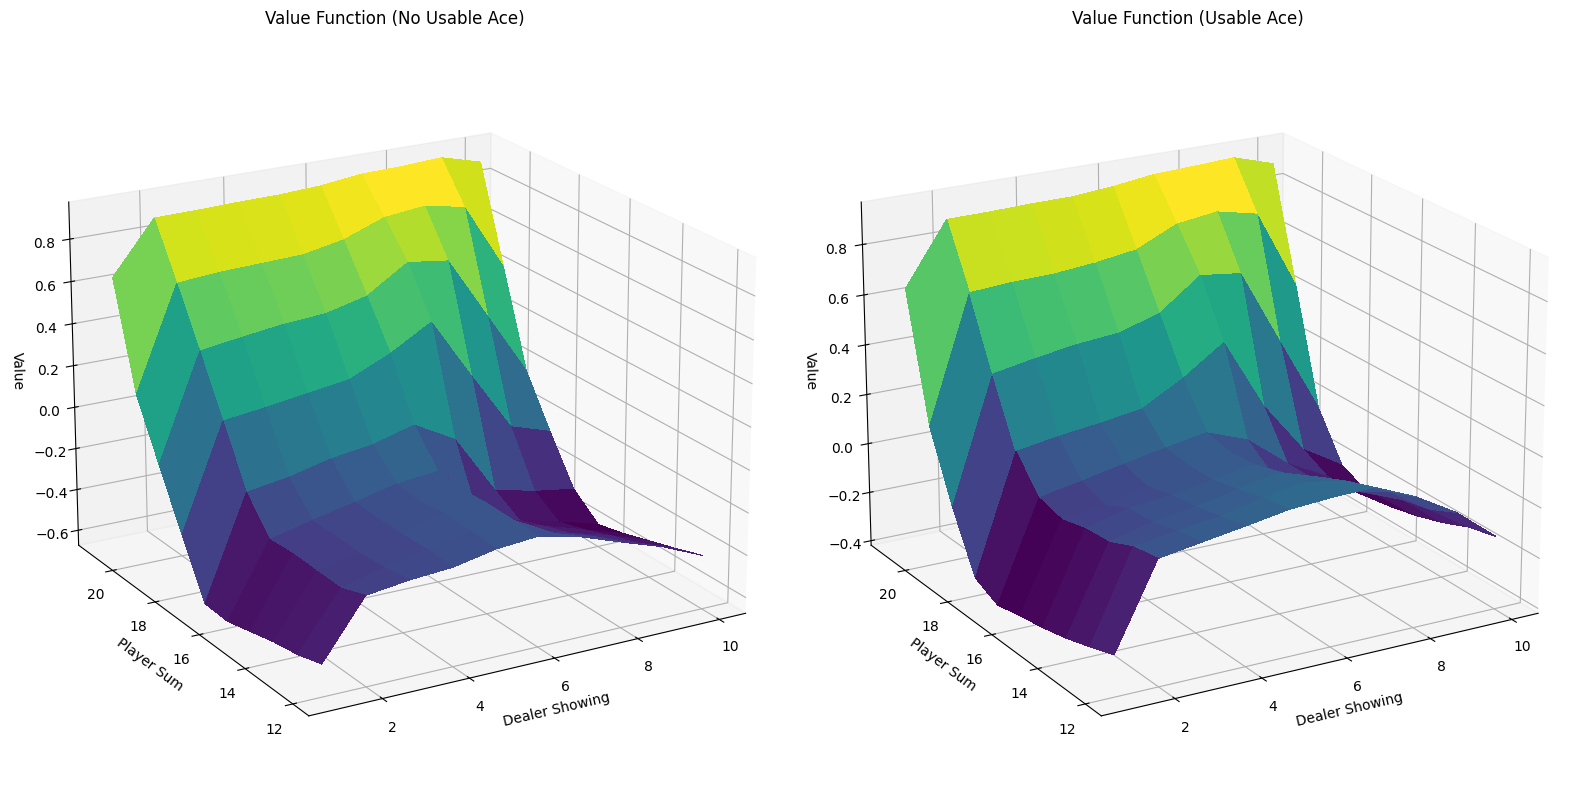

In [ ]:
# --- 4. VISUALIZATION (Policy & Value Function) ---
def plot_results(policy, Q):
    # --- PLOT 1: OPTIMAL POLICY ---
    grid_usable = np.zeros((10, 10))
    grid_no_usable = np.zeros((10, 10))

    for i, s in enumerate(range(12, 22)):
        for j, d in enumerate(range(1, 11)):
            grid_usable[i, j] = policy.get((s, d, True), 1)
            grid_no_usable[i, j] = policy.get((s, d, False), 1)

    fig1, ax1 = plt.subplots(1, 2, figsize=(12, 6))

    # Helper to clean up axes
    def set_axes(ax, title):
        ax.set_title(title)
        ax.set_xlabel("Dealer Showing")
        ax.set_ylabel("Player Sum")
        ax.set_yticks(range(12, 22))
        ax.set_xticks(range(1, 11))
        # Label Ace specially
        labels = [str(x) for x in range(1, 11)]
        labels[0] = 'A'
        ax.set_xticklabels(labels)

    ax1[0].imshow(grid_usable, origin='lower', extent=[0.5, 10.5, 11.5, 21.5], cmap='coolwarm_r')
    set_axes(ax1[0], "Policy: Usable Ace (Red=Stick, Blue=Hit)")

    ax1[1].imshow(grid_no_usable, origin='lower', extent=[0.5, 10.5, 11.5, 21.5], cmap='coolwarm_r')
    set_axes(ax1[1], "Policy: No Usable Ace (Red=Stick, Blue=Hit)")

    plt.tight_layout()
    plt.show()

    # --- PLOT 2: VALUE FUNCTION (3D) ---


    # Extract V(s) = max_a Q(s, a)
    X, Y = np.meshgrid(range(1, 11), range(12, 22))
    Z_no_usable = np.zeros(X.shape)
    Z_usable = np.zeros(X.shape)

    for i in range(X.shape[0]):     # Player Sum (rows)
        for j in range(X.shape[1]): # Dealer Card (cols)
            s = Y[i, j]
            d = X[i, j]

            # Value = max(Q(stick), Q(hit))
            Z_no_usable[i, j] = max(Q.get(((s,d,False), 0), -1), Q.get(((s,d,False), 1), -1))
            Z_usable[i, j]    = max(Q.get(((s,d,True), 0), -1),  Q.get(((s,d,True), 1), -1))

    fig2 = plt.figure(figsize=(16, 8))

    # Plot No Usable Ace
    ax2 = fig2.add_subplot(121, projection='3d')
    surf2 = ax2.plot_surface(X, Y, Z_no_usable, cmap=cm.viridis, linewidth=0, antialiased=False)
    ax2.set_title('Value Function (No Usable Ace)')
    ax2.set_xlabel('Dealer Showing')
    ax2.set_ylabel('Player Sum')
    ax2.set_zlabel('Value')
    ax2.view_init(elev=20, azim=-120) # Rotate for better view

    # Plot Usable Ace
    ax3 = fig2.add_subplot(122, projection='3d')
    surf3 = ax3.plot_surface(X, Y, Z_usable, cmap=cm.viridis, linewidth=0, antialiased=False)
    ax3.set_title('Value Function (Usable Ace)')
    ax3.set_xlabel('Dealer Showing')
    ax3.set_ylabel('Player Sum')
    ax3.set_zlabel('Value')
    ax3.view_init(elev=20, azim=-120)

    plt.tight_layout()
    plt.show()

# RUN
policy, Q_values = train(9100000)
plot_results(policy, Q_values)